# 01 - Classical DoE Baseline

This notebook builds the synthetic formulation simulator and benchmarks classical design-of-experiments (DoE) strategies before Bayesian optimization.

In [21]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import cdist

plt.style.use('seaborn-v0_8-whitegrid')

## Physics-Based Dissolution Model

This notebook uses a synthetic but physics-informed model to simulate drug dissolution behavior. The model encodes real pharmaceutical science principles:

- **HPMC (Hydroxypropyl Methylcellulose)**: Forms a viscous gel layer that retards dissolution (nonlinear quadratic penalty). Higher HPMC = slower release.
- **CCS (Croscarmellose Sodium)**: A superdisintegrant with saturable kinetics—boosts dissolution up to a point, then plateaus (captured via exponential saturation).
- **MgSt (Magnesium Stearate)**: A hydrophobic lubricant that reduces wetting and slows dissolution (strong negative effect).
- **MCC (Microcrystalline Cellulose)**: Improves wetting and compactibility (mild positive effect).
- **PVP (Polyvinylpyrrolidone)**: A solubilizer and binder (mild positive effect).
- **Interactions**: HPMC × CCS interaction term models how high HPMC reduces the effectiveness of CCS disintegration.

The model output (Q45) represents the percentage of drug released at 45 minutes—a standard dissolution metric. Real experimental measurements include noise (std=2%), making this an excellent testbed for optimization strategies.

In [22]:
import numpy as np
import pandas as pd

API_PCT = 30.0
TOTAL_EXCIPIENT_PCT = 100.0 - API_PCT

BOUNDS = {
    "hpmc": (0.0, 20.0),
    "mcc": (20.0, 60.0),
    "ccs": (1.0, 8.0),
    "mgst": (0.25, 2.0),
    "pvp": (0.0, 10.0),
}


def _physics_q45(hpmc, mcc, ccs, mgst, pvp):
    """
    Physics-informed synthetic dissolution model (% released at 45 min).

    Scientific assumptions encoded:
    - HPMC retards dissolution with nonlinear gel-layer penalty.
    - CCS improves dissolution with a saturable response.
    - MgSt reduces dissolution due to hydrophobic film formation.
    - MCC and PVP provide mild positive wetting/compactibility effects.
    - HPMC × CCS interaction reduces CCS effectiveness at high HPMC.
    """
    ccs_gain = 24.0 * (1.0 - np.exp(-ccs / 2.2))
    q45 = (
        48.0
        + 0.45 * mcc
        + 0.90 * pvp
        + ccs_gain
        - 1.05 * hpmc
        - 0.035 * (hpmc ** 2)
        - 7.2 * mgst
        - 0.16 * hpmc * ccs
    )
    return np.clip(q45, 0.0, 100.0)


def simulate_dissolution(df, noise_std=2.0, seed=0):
    """Simulate Q45 for one or many formulations."""
    rng = np.random.default_rng(seed)
    expected = _physics_q45(
        df["hpmc"].to_numpy(),
        df["mcc"].to_numpy(),
        df["ccs"].to_numpy(),
        df["mgst"].to_numpy(),
        df["pvp"].to_numpy(),
    )
    observed = expected + rng.normal(0.0, noise_std, size=len(df))
    return np.clip(observed, 0.0, 100.0)


def is_feasible(df):
    """Check formulation bounds and mass-balance constraints."""
    checks = []
    for name, (lo, hi) in BOUNDS.items():
        checks.append(df[name].between(lo, hi))
    sum_ok = np.isclose(df[["hpmc", "mcc", "ccs", "mgst", "pvp"]].sum(axis=1), TOTAL_EXCIPIENT_PCT, atol=1e-6)
    return np.logical_and.reduce(checks + [sum_ok])


def sample_feasible(n, seed=0):
    """Rejection sample feasible formulations under x5 = 70 - (x1+x2+x3+x4)."""
    rng = np.random.default_rng(seed)
    rows = []
    while len(rows) < n:
        hpmc = rng.uniform(*BOUNDS["hpmc"])
        mcc = rng.uniform(*BOUNDS["mcc"])
        ccs = rng.uniform(*BOUNDS["ccs"])
        mgst = rng.uniform(*BOUNDS["mgst"])
        pvp = TOTAL_EXCIPIENT_PCT - (hpmc + mcc + ccs + mgst)
        if BOUNDS["pvp"][0] <= pvp <= BOUNDS["pvp"][1]:
            rows.append((hpmc, mcc, ccs, mgst, pvp))
    return pd.DataFrame(rows, columns=["hpmc", "mcc", "ccs", "mgst", "pvp"])

In [23]:
# Demonstrate the physics model with sample formulations
import pandas as pd

# Sample formulations (feasible ones)
samples = pd.DataFrame([
    {"hpmc": 5.0, "mcc": 40.0, "ccs": 4.0, "mgst": 1.0, "pvp": 20.0},  # Balanced
    {"hpmc": 15.0, "mcc": 30.0, "ccs": 2.0, "mgst": 0.5, "pvp": 22.5},  # High HPMC, low CCS
    {"hpmc": 0.0, "mcc": 50.0, "ccs": 8.0, "mgst": 0.25, "pvp": 11.75},  # No HPMC, max CCS
    {"hpmc": 10.0, "mcc": 45.0, "ccs": 6.0, "mgst": 2.0, "pvp": 7.0},  # High MgSt
])

print("Sample Formulations and Predicted Q45:")
for idx, row in samples.iterrows():
    q45_clean = _physics_q45(row["hpmc"], row["mcc"], row["ccs"], row["mgst"], row["pvp"])
    q45_noisy = simulate_dissolution(pd.DataFrame([row]), seed=idx)[0]
    print(f"Sample {idx+1}: HPMC={row['hpmc']}, MCC={row['mcc']}, CCS={row['ccs']}, MgSt={row['mgst']}, PVP={row['pvp']}")
    print(f"  Q45 (expected): {q45_clean:.1f}%, Q45 (with noise): {q45_noisy:.1f}%")
    print()

Sample Formulations and Predicted Q45:
Sample 1: HPMC=5.0, MCC=40.0, CCS=4.0, MgSt=1.0, PVP=20.0
  Q45 (expected): 87.6%, Q45 (with noise): 87.8%

Sample 2: HPMC=15.0, MCC=30.0, CCS=2.0, MgSt=0.5, PVP=22.5
  Q45 (expected): 64.1%, Q45 (with noise): 64.7%

Sample 3: HPMC=0.0, MCC=50.0, CCS=8.0, MgSt=0.25, PVP=11.75
  Q45 (expected): 100.0%, Q45 (with noise): 100.0%

Sample 4: HPMC=10.0, MCC=45.0, CCS=6.0, MgSt=2.0, PVP=7.0
  Q45 (expected): 59.0%, Q45 (with noise): 63.1%



## Understanding 3 Levels × 5 Factors Design

A **3 × 5 full-factorial design** tests all possible combinations of factor levels:

**Factors** (5): The excipients we can vary
- HPMC, MCC, CCS, MgSt, PVP

**Levels** (3): Each factor is tested at 3 settings
- Low, Medium, High (e.g., HPMC: 0%, 10%, 20%)

**Total Combinations**: $3^5 = 243$ unique formulations

### The Problem with Full-Factorial under a strict mass-balance:
- ✓ Tests all combinations systematically
- ✗ Many points are infeasible once we enforce `hpmc + mcc + ccs + mgst + pvp = 70`
- ✗ With only 3 discrete levels per factor, the exact-sum constraint can leave very few feasible points

In the next cell, we explicitly count feasible points in this **discrete** 3-level grid.
That count is only for this grid, not for the continuous constrained design space.


In [24]:
levels = {
    k: np.linspace(v[0], v[1], 3)
    for k, v in BOUNDS.items()
}

factorial = pd.DataFrame(
    list(product(levels["hpmc"], levels["mcc"], levels["ccs"], levels["mgst"], levels["pvp"])),
    columns=["hpmc", "mcc", "ccs", "mgst", "pvp"],
)
factorial["sum_excipient"] = factorial[["hpmc", "mcc", "ccs", "mgst", "pvp"]].sum(axis=1)
factorial["feasible"] = is_feasible(factorial)

n_total = len(factorial)
n_feasible = int(factorial["feasible"].sum())

print(f"Full-factorial combinations: {n_total}")
print(f"Feasible under strict mass-balance + bounds: {n_feasible} ({100*n_feasible/n_total:.1f}%)")
print("Interpretation: a 3-level discrete grid collapses under this constraint, so we move to continuous constrained sampling.")


Full-factorial combinations: 243
Feasible under strict mass-balance + bounds: 3 (1.2%)
Interpretation: a 3-level discrete grid collapses under this constraint, so we move to continuous constrained sampling.


## Space-filling D-optimal proxy and CCD-style design

### Why can we still get 20 runs if the 3-level grid has very few feasible points?
The 3-level factorial count is only a **discrete lattice** check.
For D-opt proxy and CCD-style design, we do **not** sample only those few lattice points.

Instead, we generate a new **continuous feasible candidate pool** using `sample_feasible(...)`:
- Draw continuous values for HPMC, MCC, CCS, MgSt within bounds
- Compute `pvp = 70 - (hpmc + mcc + ccs + mgst)`
- Keep the point only if `pvp` is within `[0, 10]`

Then:
- **D-opt proxy (greedy maximin)** selects 20 space-filling points from that feasible pool.
- **CCD-style** starts from a feasible center, keeps only feasible axial perturbations, and tops up with additional feasible samples to reach 20.


In [25]:
# Create a large candidate pool in the continuous constrained space.
candidate_pool = sample_feasible(4000, seed=7)

# Important diagnostic: discrete-grid feasibility and continuous-space feasibility are different.
factorial_feasible_n = int(factorial["feasible"].sum())
print(f"Feasible points in 3-level full-factorial grid: {factorial_feasible_n}")
print(f"Feasible points in continuous candidate pool used here: {len(candidate_pool)}")

# Greedy maximin point selection as a practical D-optimal proxy.
def greedy_maximin(df, n_select, seed=0):
    rng = np.random.default_rng(seed)
    X = df[["hpmc", "mcc", "ccs", "mgst", "pvp"]].to_numpy()
    chosen = [rng.integers(0, len(df))]
    min_dist = cdist(X, X[chosen]).ravel()
    for _ in range(n_select - 1):
        idx = int(np.argmax(min_dist))
        chosen.append(idx)
        min_dist = np.minimum(min_dist, cdist(X, X[[idx]]).ravel())
    return df.iloc[chosen].reset_index(drop=True)

# CCD-like set: center + axial perturbations + random face points, all projected via feasibility check.
center = sample_feasible(1, seed=12).iloc[0]
ccd_rows = [{**center.to_dict(), "ccd_role": "center"}]
step = {"hpmc": 4.0, "mcc": 8.0, "ccs": 1.5, "mgst": 0.35}
for factor in ["hpmc", "mcc", "ccs", "mgst"]:
    for sign in [-1, 1]:
        row = center.copy()
        row[factor] = np.clip(row[factor] + sign * step[factor], *BOUNDS[factor])
        row["pvp"] = TOTAL_EXCIPIENT_PCT - (row["hpmc"] + row["mcc"] + row["ccs"] + row["mgst"])
        if BOUNDS["pvp"][0] <= row["pvp"] <= BOUNDS["pvp"][1]:
            ccd_rows.append({**row.to_dict(), "ccd_role": f"axial_{factor}_{'plus' if sign > 0 else 'minus'}"})

while len(ccd_rows) < 20:
    row = sample_feasible(1, seed=100 + len(ccd_rows)).iloc[0]
    ccd_rows.append({**row.to_dict(), "ccd_role": "topup_feasible"})

ccd = pd.DataFrame(ccd_rows)
ccd = ccd.drop_duplicates(subset=["hpmc", "mcc", "ccs", "mgst", "pvp"]).head(20).reset_index(drop=True)

d_opt_proxy = greedy_maximin(candidate_pool, n_select=20, seed=21)

d_opt_proxy["q45"] = simulate_dissolution(d_opt_proxy, seed=21)
ccd["q45"] = simulate_dissolution(ccd, seed=22)

ccd["ccd_group"] = np.where(
    ccd["ccd_role"].str.startswith("axial"),
    "axial",
    np.where(ccd["ccd_role"] == "center", "center", "topup"),
)

print("\nSelected design sizes from constrained continuous space:")
print(f"D-optimal proxy runs: {len(d_opt_proxy)}")
print(f"CCD-style runs: {len(ccd)}")
print("CCD role counts:")
print(ccd["ccd_group"].value_counts())


Feasible points in 3-level full-factorial grid: 3
Feasible points in continuous candidate pool used here: 4000

Selected design sizes from constrained continuous space:
D-optimal proxy runs: 20
CCD-style runs: 20
CCD role counts:
ccd_group
topup     12
axial      7
center     1
Name: count, dtype: int64


## Quadratic RSM fit and RMSE

In [26]:
train = pd.concat([d_opt_proxy.assign(design="d_opt"), ccd.assign(design="ccd")], ignore_index=True)
test = sample_feasible(500, seed=99)
test["q45"] = simulate_dissolution(test, seed=99)

features = ["hpmc", "mcc", "ccs", "mgst", "pvp"]
X_train, y_train = train[features], train["q45"]
X_test, y_test = test[features], test["q45"]

rsm = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("reg", LinearRegression()),
])
rsm.fit(X_train, y_train)
y_pred = rsm.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RSM (quadratic) RMSE on holdout: {rmse:.2f} Q45 points")

RSM (quadratic) RMSE on holdout: 2.49 Q45 points


## Response-surface slice: HPMC vs CCS

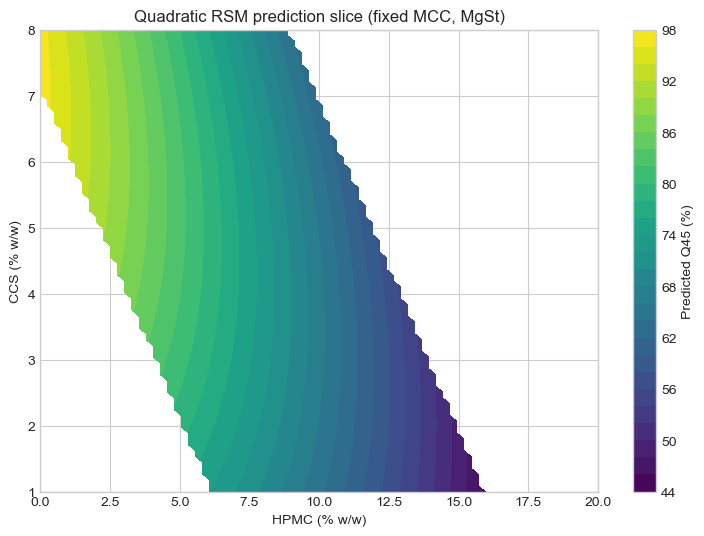

In [27]:
fixed = {
    "mcc": float(train["mcc"].median()),
    "mgst": float(train["mgst"].median()),
}

hpmc_grid = np.linspace(*BOUNDS["hpmc"], 80)
ccs_grid = np.linspace(*BOUNDS["ccs"], 80)
Z = np.full((len(ccs_grid), len(hpmc_grid)), np.nan)

for i, ccs in enumerate(ccs_grid):
    for j, hpmc in enumerate(hpmc_grid):
        pvp = TOTAL_EXCIPIENT_PCT - (hpmc + fixed["mcc"] + ccs + fixed["mgst"])
        if BOUNDS["pvp"][0] <= pvp <= BOUNDS["pvp"][1]:
            row = pd.DataFrame([{
                "hpmc": hpmc,
                "mcc": fixed["mcc"],
                "ccs": ccs,
                "mgst": fixed["mgst"],
                "pvp": pvp,
            }])
            Z[i, j] = rsm.predict(row)[0]

fig, ax = plt.subplots(figsize=(9, 6))
mesh = ax.contourf(hpmc_grid, ccs_grid, Z, levels=25, cmap="viridis")
ax.set_title("Quadratic RSM prediction slice (fixed MCC, MgSt)")
ax.set_xlabel("HPMC (% w/w)")
ax.set_ylabel("CCS (% w/w)")
fig.colorbar(mesh, ax=ax, label="Predicted Q45 (%)")
plt.show()

## Baseline takeaways

- Unconstrained full-factorial design scales poorly and wastes infeasible runs under mass-balance constraints.
- Small classical designs (CCD / D-opt-like) are efficient but model-naive and can miss high-performing nonlinear regions.
- This motivates Bayesian optimization to balance exploration and exploitation with uncertainty awareness.